# Propulsion Power Prediction (v2.0 - Combined Training)

This notebook provides a complete workflow for training, evaluating, and testing propulsion power prediction models.

**Version 2.0 Update**: Models are now trained on **combined synthetic + real data** for improved generalization. Evaluation is performed separately on both synthetic and real dev sets.

## Contents
1. Setup & Configuration
2. Data Loading & Exploration (Combined Synthetic + Real)
3. Feature Engineering
4. Baseline Models
5. Neural Network Models
6. Uncertainty Quantification
7. Model Comparison (Synthetic vs Real Performance)
8. Distribution Shift Analysis
9. Making Predictions on New Data


## 1. Setup & Configuration


In [8]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Add models directory to path
sys.path.insert(0, 'models')
sys.path.insert(0, 'utils')

# Import our modules
from config import Config, default_config
from data_module import PropulsionDataModule, CombinedDataModule
from baseline_models import create_baseline_model, MeanBaseline, LinearModel, RandomForestModel
from neural_models import create_mlp, NeuralNetworkTrainer, MLP, GaussianMLP
from uncertainty import DeepEnsemble, MCDropout, compute_uncertainty_metrics
from assessment import get_performance_metric

# PyTorch
import torch

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")


PyTorch version: 2.6.0+cu124
Device: CUDA


In [9]:
# Configuration
config = Config()

# Data directories for combined training
SYNTHETIC_DATA_DIR = "data/synthetic_data"
REAL_DATA_DIR = "data/real_data"

# You can modify settings here
config.model.max_epochs = 100
config.model.batch_size = 256
config.model.n_ensemble_members = 5
config.model.early_stopping_patience = 10

# Create output directories
os.makedirs(config.output_dir, exist_ok=True)
os.makedirs(config.checkpoint_dir, exist_ok=True)

print("Configuration:")
print(f"  Synthetic data directory: {SYNTHETIC_DATA_DIR}")
print(f"  Real data directory: {REAL_DATA_DIR}")
print(f"  Training approach: COMBINED (synthetic + real)")
print(f"  Max epochs: {config.model.max_epochs}")
print(f"  Batch size: {config.model.batch_size}")
print(f"  Ensemble members: {config.model.n_ensemble_members}")


Configuration:
  Synthetic data directory: data/synthetic_data
  Real data directory: data/real_data
  Training approach: COMBINED (synthetic + real)
  Max epochs: 100
  Batch size: 256
  Ensemble members: 5


## 2. Data Loading & Exploration


In [10]:
# Initialize and setup combined data module (synthetic + real)
data_module = CombinedDataModule(config.data)
data_module.setup(synthetic_dir=SYNTHETIC_DATA_DIR, real_dir=REAL_DATA_DIR)


Loading synthetic data...
  Synthetic Train: 523,190 samples
  Synthetic Dev-in: 18,108 samples
  Synthetic Dev-out: 18,108 samples

Loading real data...
  Real Train: 530,706 samples
  Real Dev-in: 18,368 samples
  Real Dev-out: 18,368 samples

📊 Combined Training Data: 1,053,896 samples
   (523,190 synthetic + 530,706 real)

Applying feature engineering...
  Using 19 features

Splitting combined train into train/val (90%/10%)...
  Train split: 948,506 samples
  Val split: 105,390 samples

Fitting scalers on combined training data only...

✓ Combined data module setup complete.


In [11]:
# Check the data
print("\nFeature columns:")
for i, col in enumerate(data_module.feature_columns):
    print(f"  {i+1}. {col}")

print(f"\nTotal features: {data_module.n_features}")



Feature columns:
  1. draft_aft_telegram
  2. draft_fore_telegram
  3. stw
  4. diff_speed_overground
  5. awind_vcomp_provider
  6. awind_ucomp_provider
  7. rcurrent_vcomp
  8. rcurrent_ucomp
  9. comb_wind_swell_wave_height
  10. timeSinceDryDock
  11. stw_cubed
  12. stw_squared
  13. mean_draft
  14. trim
  15. wind_magnitude
  16. wind_angle
  17. current_magnitude
  18. current_angle
  19. speed_wind_interaction

Total features: 19


In [12]:
# Get raw data for exploration
train_df = data_module.train_df
val_df = data_module.val_df

# Separate dev sets for each domain
synthetic_dev_in_df = data_module.synthetic_dev_in_df
synthetic_dev_out_df = data_module.synthetic_dev_out_df
real_dev_in_df = data_module.real_dev_in_df
real_dev_out_df = data_module.real_dev_out_df

print("Combined Dataset Summary:")
print(f"  Training: {len(train_df):,} samples ({data_module.synthetic_train_size:,} synthetic + {data_module.real_train_size:,} real)")
print(f"  Validation: {len(val_df):,} samples")
print(f"\nDev Sets (for evaluation):")
print(f"  Synthetic Dev-in: {len(synthetic_dev_in_df):,} samples")
print(f"  Synthetic Dev-out: {len(synthetic_dev_out_df):,} samples")
print(f"  Real Dev-in: {len(real_dev_in_df):,} samples")
print(f"  Real Dev-out: {len(real_dev_out_df):,} samples")
print("\nTraining dataset statistics:")
train_df.describe()


Combined Dataset Summary:
  Training: 948,506 samples (523,190 synthetic + 530,706 real)
  Validation: 105,390 samples

Dev Sets (for evaluation):
  Synthetic Dev-in: 18,108 samples
  Synthetic Dev-out: 18,108 samples
  Real Dev-in: 18,368 samples
  Real Dev-out: 18,368 samples

Training dataset statistics:


,draft_aft_telegram,draft_fore_telegram,stw,diff_speed_overground,awind_vcomp_provider,awind_ucomp_provider,rcurrent_vcomp,rcurrent_ucomp,comb_wind_swell_wave_height,timeSinceDryDock,power,stw_cubed,stw_squared,mean_draft,trim,wind_magnitude,wind_angle,current_magnitude,current_angle,speed_wind_interaction
count,948506.000000,948506.000000,948506.000000,948506.000000,948506.000000,948506.000000,948506.000000,948506.000000,948506.000000,9.485060e+05,948506.000000,948506.000000,948506.000000,948506.000000,948506.000000,948506.000000,948506.000000,948506.000000,948506.000000,948506.000000
mean,12.267866,12.020922,17.290275,0.000914,16.427399,6.003933,0.005477,0.000442,1.565920,9.746186e+05,19153.327038,5586.337339,307.470696,12.144394,0.246944,18.414405,0.445648,0.439035,-0.020090,322.194961
std,1.486311,1.682088,2.918405,0.242417,8.877396,4.543343,0.472588,0.342784,0.865762,4.564043e+05,8205.559470,2327.415918,93.192667,1.566036,0.516920,8.140419,0.428031,0.384862,1.821245,159.213577
min,7.246647,5.900000,4.470901,-2.460733,-12.988231,-1.308256,-2.070998,-2.022287,-0.365431,1.077600e+04,-708.889408,89.368625,19.988953,6.800000,-1.276627,0.005098,-3.101096,0.000000,-3.141593,0.082316
25%,11.100000,10.864015,15.160600,-0.100000,9.743304,2.317685,-0.189368,-0.152072,0.966797,6.529970e+05,11627.074464,3484.569597,229.843784,11.000000,0.000000,12.398884,0.139844,0.164750,-1.483545,200.623694
50%,12.570871,12.387623,18.364428,0.000000,16.254372,4.890185,0.012740,-0.005786,1.467500,1.034806e+06,20807.902776,6193.444378,337.252228,12.492425,0.100000,18.109263,0.320861,0.306912,-0.050615,308.655476
75%,13.400000,13.350000,19.263399,0.100000,23.050463,8.874844,0.201552,0.147463,2.051649,1.361258e+06,24972.000000,7148.234134,371.078546,13.275163,0.350000,24.429830,0.632980,0.593341,1.492791,434.441422
max,15.209577,15.394316,24.085847,2.623826,41.235331,20.233041,2.106009,2.038281,5.566446,1.735545e+06,43883.000000,13972.874313,580.128010,15.093283,3.725139,41.396218,3.141174,2.140270,3.141593,892.213862


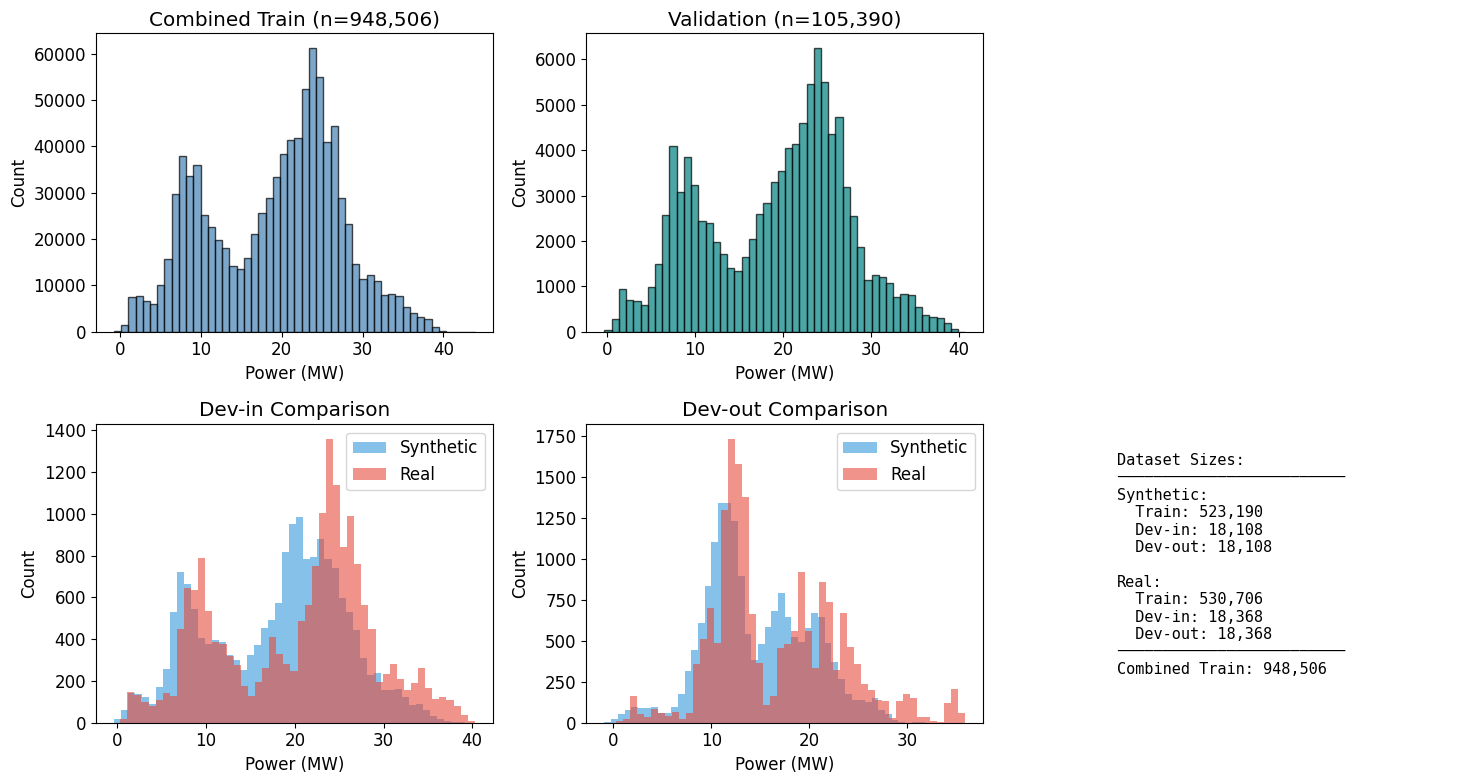

In [13]:
# Visualize target distribution across splits
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Top row: Combined training and validation
ax = axes[0, 0]
ax.hist(train_df['power'] / 1000, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
ax.set_xlabel('Power (MW)')
ax.set_ylabel('Count')
ax.set_title(f'Combined Train (n={len(train_df):,})')

ax = axes[0, 1]
ax.hist(val_df['power'] / 1000, bins=50, alpha=0.7, edgecolor='black', color='teal')
ax.set_xlabel('Power (MW)')
ax.set_ylabel('Count')
ax.set_title(f'Validation (n={len(val_df):,})')

axes[0, 2].axis('off')  # Empty for layout

# Bottom row: Synthetic vs Real dev sets
ax = axes[1, 0]
ax.hist(synthetic_dev_in_df['power'] / 1000, bins=50, alpha=0.6, label='Synthetic', color='#3498db')
ax.hist(real_dev_in_df['power'] / 1000, bins=50, alpha=0.6, label='Real', color='#e74c3c')
ax.set_xlabel('Power (MW)')
ax.set_ylabel('Count')
ax.set_title('Dev-in Comparison')
ax.legend()

ax = axes[1, 1]
ax.hist(synthetic_dev_out_df['power'] / 1000, bins=50, alpha=0.6, label='Synthetic', color='#3498db')
ax.hist(real_dev_out_df['power'] / 1000, bins=50, alpha=0.6, label='Real', color='#e74c3c')
ax.set_xlabel('Power (MW)')
ax.set_ylabel('Count')
ax.set_title('Dev-out Comparison')
ax.legend()

# Summary stats
ax = axes[1, 2]
ax.axis('off')
summary_text = f"""Dataset Sizes:
─────────────────────────
Synthetic:
  Train: {data_module.synthetic_train_size:,}
  Dev-in: {len(synthetic_dev_in_df):,}
  Dev-out: {len(synthetic_dev_out_df):,}

Real:
  Train: {data_module.real_train_size:,}
  Dev-in: {len(real_dev_in_df):,}
  Dev-out: {len(real_dev_out_df):,}
─────────────────────────
Combined Train: {len(train_df):,}
"""
ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.show()


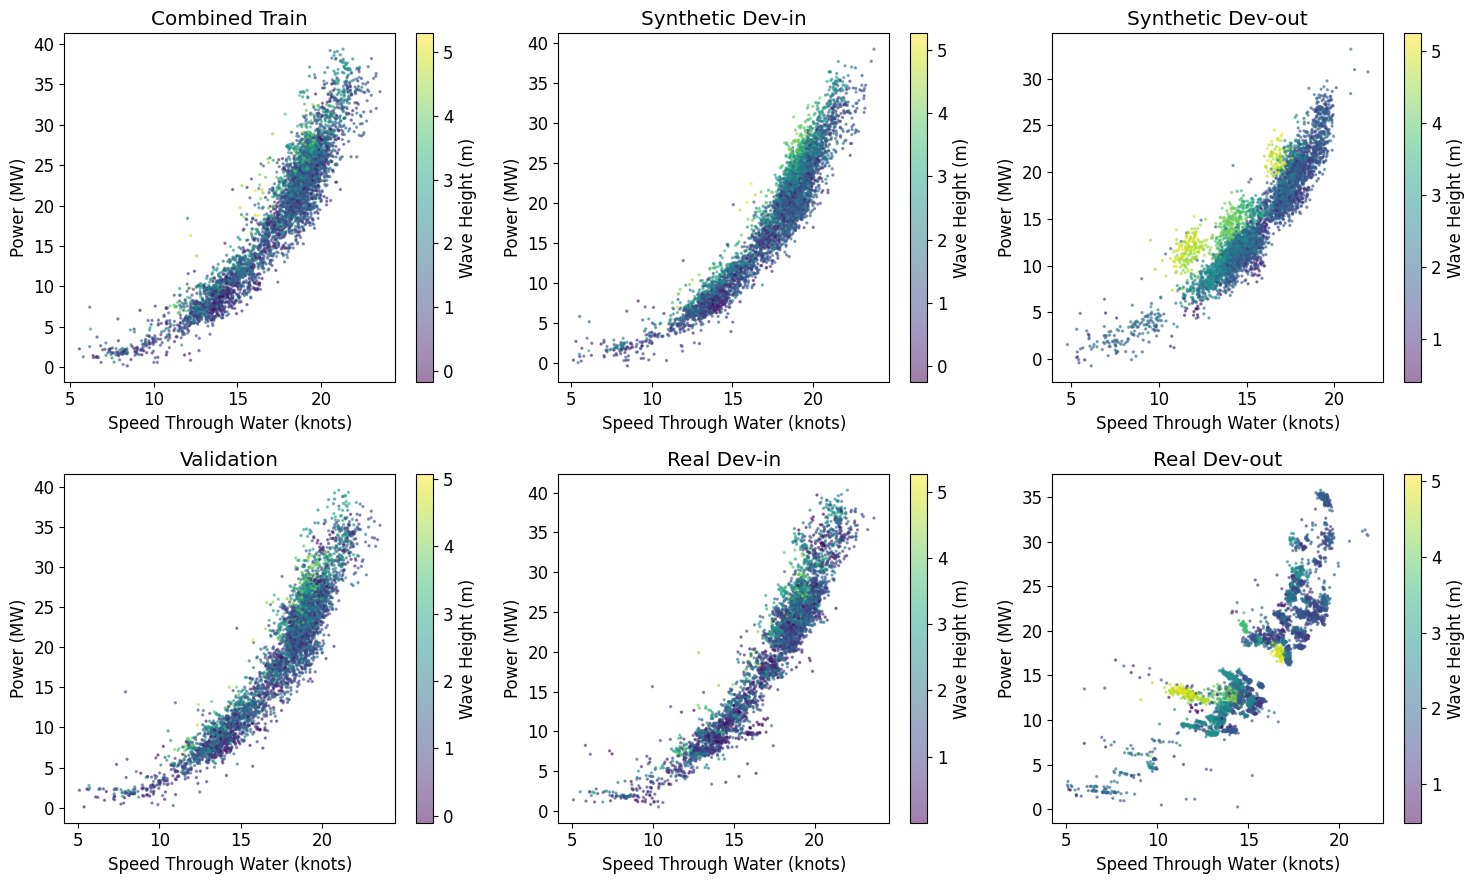

In [14]:
# Power vs Speed relationship - comparing domains
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

datasets = [
    ('Combined Train', train_df),
    ('Synthetic Dev-in', synthetic_dev_in_df),
    ('Synthetic Dev-out', synthetic_dev_out_df),
    ('Validation', val_df),
    ('Real Dev-in', real_dev_in_df),
    ('Real Dev-out', real_dev_out_df)
]

for ax, (name, df) in zip(axes.flatten(), datasets):
    sample = df.sample(min(5000, len(df)), random_state=42)
    scatter = ax.scatter(sample['stw'], sample['power'] / 1000, 
                         c=sample['comb_wind_swell_wave_height'], 
                         s=2, alpha=0.5, cmap='viridis')
    ax.set_xlabel('Speed Through Water (knots)')
    ax.set_ylabel('Power (MW)')
    ax.set_title(f'{name}')
    plt.colorbar(scatter, ax=ax, label='Wave Height (m)')

plt.tight_layout()
plt.show()


## 3. Feature Engineering

The data module automatically applies feature engineering. Let's see what features were created.


In [15]:
# Show engineered features
base_features = config.data.base_features
engineered_features = [f for f in data_module.feature_columns if f not in base_features]

print("Base features:")
for f in base_features:
    print(f"  - {f}")

print("\nEngineered features:")
for f in engineered_features:
    print(f"  - {f}")


Base features:
  - draft_aft_telegram
  - draft_fore_telegram
  - stw
  - diff_speed_overground
  - awind_vcomp_provider
  - awind_ucomp_provider
  - rcurrent_vcomp
  - rcurrent_ucomp
  - comb_wind_swell_wave_height
  - timeSinceDryDock

Engineered features:
  - stw_cubed
  - stw_squared
  - mean_draft
  - trim
  - wind_magnitude
  - wind_angle
  - current_magnitude
  - current_angle
  - speed_wind_interaction


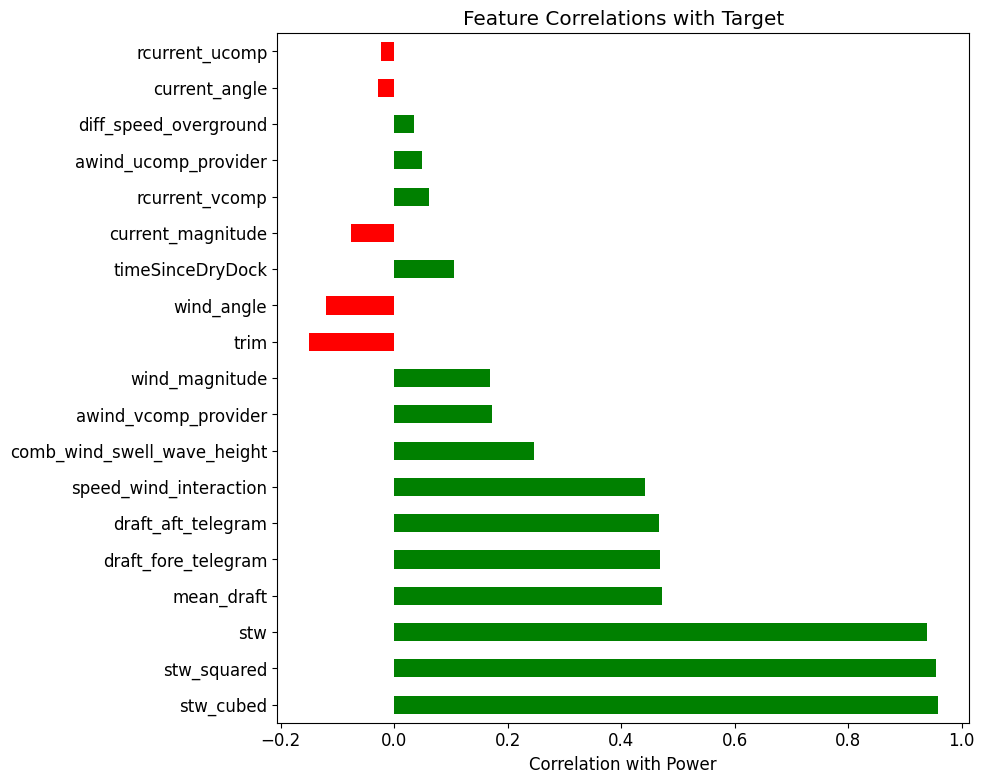

In [9]:
# Correlation with target
correlations = train_df[data_module.feature_columns + ['power']].corr()['power'].drop('power').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color=['green' if x > 0 else 'red' for x in correlations])
plt.xlabel('Correlation with Power')
plt.title('Feature Correlations with Target')
plt.tight_layout()
plt.show()


## 4. Baseline Models

Let's train and evaluate baseline models to establish performance benchmarks.


In [16]:
# Get scaled data - combined training + separate dev sets per domain
X_train, y_train = data_module.get_train_data()
X_val, y_val = data_module.get_val_data()

# Synthetic dev sets
X_syn_dev_in, y_syn_dev_in = data_module.get_synthetic_dev_in_data()
X_syn_dev_out, y_syn_dev_out = data_module.get_synthetic_dev_out_data()

# Real dev sets
X_real_dev_in, y_real_dev_in = data_module.get_real_dev_in_data()
X_real_dev_out, y_real_dev_out = data_module.get_real_dev_out_data()

print(f"Combined training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"\nSynthetic dev sets:")
print(f"  Dev-in: {X_syn_dev_in.shape}")
print(f"  Dev-out: {X_syn_dev_out.shape}")
print(f"\nReal dev sets:")
print(f"  Dev-in: {X_real_dev_in.shape}")
print(f"  Dev-out: {X_real_dev_out.shape}")


Combined training data shape: (948506, 19)
Validation data shape: (105390, 19)

Synthetic dev sets:
  Dev-in: (18108, 19)
  Dev-out: (18108, 19)

Real dev sets:
  Dev-in: (18368, 19)
  Dev-out: (18368, 19)


In [17]:
# Helper function to evaluate a model on all dev sets
def evaluate_model(model, name, X_train, y_train, data_module):
    """Train and evaluate a model on all splits (both synthetic and real)."""
    
    # Train
    model.fit(X_train, y_train)
    
    results = {}
    
    # Define all evaluation splits
    eval_splits = [
        ('val', (X_val, y_val)),
        ('syn_dev_in', (X_syn_dev_in, y_syn_dev_in)),
        ('syn_dev_out', (X_syn_dev_out, y_syn_dev_out)),
        ('real_dev_in', (X_real_dev_in, y_real_dev_in)),
        ('real_dev_out', (X_real_dev_out, y_real_dev_out))
    ]
    
    for split_name, (X, y) in eval_splits:
        y_pred = model.predict(X)
        
        # Scaled metrics
        mae_scaled = np.mean(np.abs(y_pred - y))
        rmse_scaled = np.sqrt(np.mean((y_pred - y) ** 2))
        
        # Original scale (kW)
        y_pred_kw = data_module.inverse_transform_predictions(y_pred)
        y_true_kw = data_module.inverse_transform_predictions(y)
        mae_kw = np.mean(np.abs(y_pred_kw - y_true_kw))
        
        results[split_name] = {
            'mae_scaled': mae_scaled,
            'rmse_scaled': rmse_scaled,
            'mae_kw': mae_kw
        }
    
    return results


In [18]:
# Train baseline models on combined data
baseline_results = {}

# Mean baseline
print("Training Mean Baseline on combined data...")
mean_model = create_baseline_model('mean', config.model)
baseline_results['Mean'] = evaluate_model(mean_model, 'Mean', X_train, y_train, data_module)

# Linear regression
print("Training Linear Regression on combined data...")
linear_model = create_baseline_model('linear', config.model)
baseline_results['Linear'] = evaluate_model(linear_model, 'Linear', X_train, y_train, data_module)

# Random Forest
print("Training Random Forest on combined data...")
rf_model = create_baseline_model('rf', config.model)
baseline_results['Random Forest'] = evaluate_model(rf_model, 'RF', X_train, y_train, data_module)

# XGBoost (if available)
try:
    print("Training XGBoost on combined data...")
    xgb_model = create_baseline_model('xgboost', config.model)
    xgb_model.fit(X_train, y_train, X_val, y_val)  # With early stopping
    
    # Evaluate manually since we already fitted
    xgb_results = {}
    eval_splits = [
        ('val', (X_val, y_val)),
        ('syn_dev_in', (X_syn_dev_in, y_syn_dev_in)),
        ('syn_dev_out', (X_syn_dev_out, y_syn_dev_out)),
        ('real_dev_in', (X_real_dev_in, y_real_dev_in)),
        ('real_dev_out', (X_real_dev_out, y_real_dev_out))
    ]
    for split_name, (X, y) in eval_splits:
        y_pred = xgb_model.predict(X)
        y_pred_kw = data_module.inverse_transform_predictions(y_pred)
        y_true_kw = data_module.inverse_transform_predictions(y)
        xgb_results[split_name] = {
            'mae_scaled': np.mean(np.abs(y_pred - y)),
            'rmse_scaled': np.sqrt(np.mean((y_pred - y) ** 2)),
            'mae_kw': np.mean(np.abs(y_pred_kw - y_true_kw))
        }
    baseline_results['XGBoost'] = xgb_results
except ImportError:
    print("XGBoost not available, skipping...")

print("\n✓ Done training baseline models on combined data!")


Training Mean Baseline on combined data...
Training Linear Regression on combined data...
Training Random Forest on combined data...
Training XGBoost on combined data...

✓ Done training baseline models on combined data!


In [19]:
# Display baseline results - separate tables for synthetic and real
print("\n" + "="*80)
print("BASELINE MODEL RESULTS (MAE in kW) - Trained on Combined Data")
print("="*80)

print("\n📊 SYNTHETIC DATA EVALUATION:")
print("-"*60)
print(f"{'Model':<20} {'Validation':<15} {'Dev-in':<15} {'Dev-out':<15}")
print("-"*60)
for name, results in baseline_results.items():
    val = results['val']['mae_kw']
    dev_in = results['syn_dev_in']['mae_kw']
    dev_out = results['syn_dev_out']['mae_kw']
    print(f"{name:<20} {val:<15.2f} {dev_in:<15.2f} {dev_out:<15.2f}")

print("\n📊 REAL DATA EVALUATION:")
print("-"*60)
print(f"{'Model':<20} {'Validation':<15} {'Dev-in':<15} {'Dev-out':<15}")
print("-"*60)
for name, results in baseline_results.items():
    val = results['val']['mae_kw']
    dev_in = results['real_dev_in']['mae_kw']
    dev_out = results['real_dev_out']['mae_kw']
    print(f"{name:<20} {val:<15.2f} {dev_in:<15.2f} {dev_out:<15.2f}")



BASELINE MODEL RESULTS (MAE in kW) - Trained on Combined Data

📊 SYNTHETIC DATA EVALUATION:
------------------------------------------------------------
Model                Validation      Dev-in          Dev-out        
------------------------------------------------------------
Mean                 6884.69         6332.50         5902.46        
Linear               1561.67         1565.31         1417.63        
Random Forest        490.41          723.10          1179.16        
XGBoost              762.11          868.41          990.55         

📊 REAL DATA EVALUATION:
------------------------------------------------------------
Model                Validation      Dev-in          Dev-out        
------------------------------------------------------------
Mean                 6884.69         7483.87         5870.38        
Linear               1561.67         1587.98         1643.81        
Random Forest        490.41          267.43          2232.26        
XGBoost          

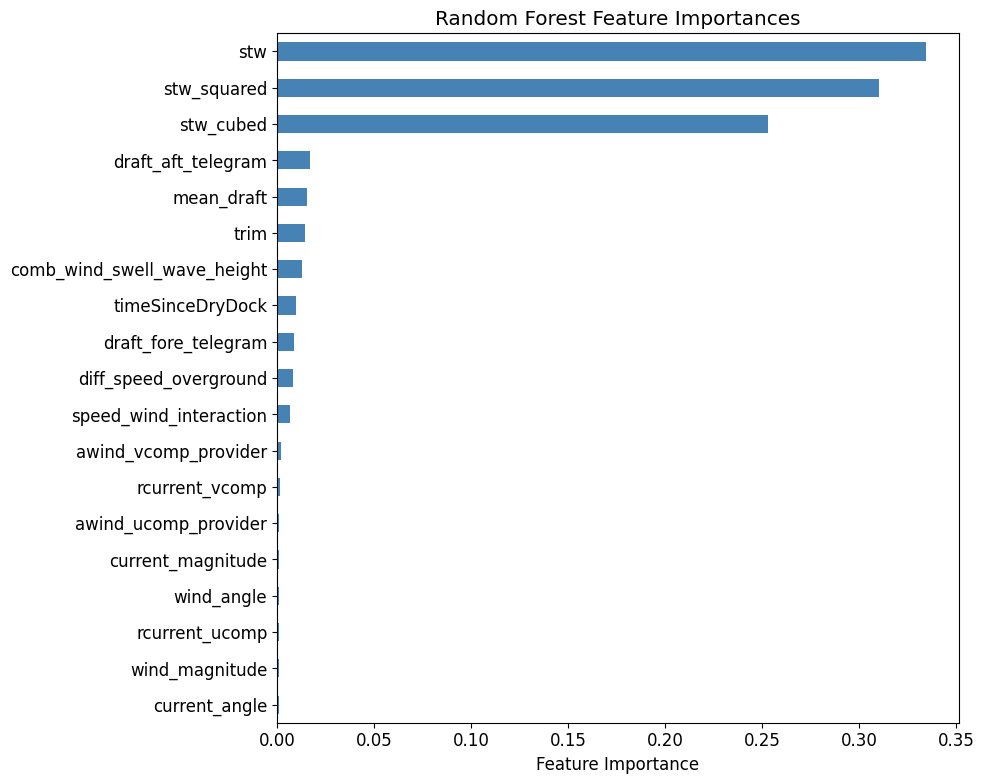

In [20]:
# Feature importance from Random Forest
if hasattr(rf_model, 'feature_importances_'):
    importance = pd.Series(rf_model.feature_importances_, index=data_module.feature_columns)
    importance = importance.sort_values(ascending=True)
    
    plt.figure(figsize=(10, 8))
    importance.plot(kind='barh', color='steelblue')
    plt.xlabel('Feature Importance')
    plt.title('Random Forest Feature Importances')
    plt.tight_layout()
    plt.show()


## 5. Neural Network Models


In [21]:
# Train MLP
print("Training MLP...")
print(f"Architecture: {config.model.hidden_layers}")
print(f"Dropout: {config.model.dropout_rate}")

torch.manual_seed(SEED)
mlp_model = create_mlp(
    input_dim=data_module.n_features,
    config=config.model,
    gaussian_output=False
)

mlp_trainer = NeuralNetworkTrainer(
    model=mlp_model,
    learning_rate=config.model.learning_rate,
    batch_size=config.model.batch_size,
    max_epochs=config.model.max_epochs,
    early_stopping_patience=config.model.early_stopping_patience
)

mlp_history = mlp_trainer.train(X_train, y_train, X_val, y_val, verbose=True)


Training MLP...
Architecture: [128, 64, 32]
Dropout: 0.2
Epoch 10/100 - Train Loss: 0.056133, Val Loss: 0.035215
Epoch 20/100 - Train Loss: 0.053053, Val Loss: 0.033963
Epoch 30/100 - Train Loss: 0.052275, Val Loss: 0.032908
Early stopping at epoch 34


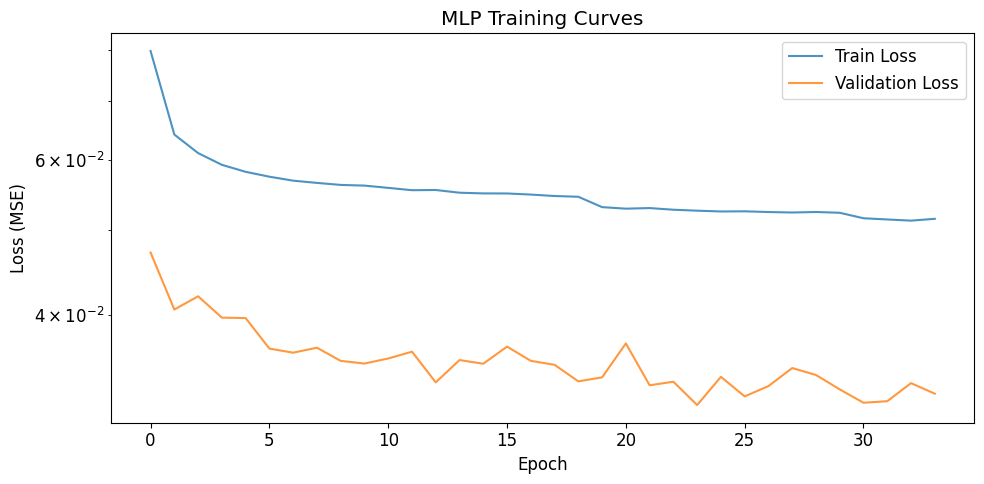

Best validation loss: 0.031587
Epochs trained: 34


In [23]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(mlp_history['train_losses'], label='Train Loss', alpha=0.8)
ax.plot(mlp_history['val_losses'], label='Validation Loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('MLP Training Curves')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print(f"Best validation loss: {mlp_history['best_val_loss']:.6f}")
print(f"Epochs trained: {mlp_history['epochs_trained']}")


In [24]:
# Evaluate MLP on all dev sets
mlp_results = {}

eval_splits = [
    ('val', (X_val, y_val)),
    ('syn_dev_in', (X_syn_dev_in, y_syn_dev_in)),
    ('syn_dev_out', (X_syn_dev_out, y_syn_dev_out)),
    ('real_dev_in', (X_real_dev_in, y_real_dev_in)),
    ('real_dev_out', (X_real_dev_out, y_real_dev_out))
]

print("MLP Evaluation Results:")
print("-" * 40)
for split_name, (X, y) in eval_splits:
    y_pred = mlp_trainer.predict(X)
    
    y_pred_kw = data_module.inverse_transform_predictions(y_pred)
    y_true_kw = data_module.inverse_transform_predictions(y)
    
    mlp_results[split_name] = {
        'mae_scaled': np.mean(np.abs(y_pred - y)),
        'mae_kw': np.mean(np.abs(y_pred_kw - y_true_kw)),
        'rmse_kw': np.sqrt(np.mean((y_pred_kw - y_true_kw) ** 2))
    }
    print(f"  {split_name}: MAE = {mlp_results[split_name]['mae_kw']:.2f} kW")


MLP Evaluation Results:
----------------------------------------
  val: MAE = 1044.92 kW
  syn_dev_in: MAE = 1111.72 kW
  syn_dev_out: MAE = 1222.44 kW
  real_dev_in: MAE = 998.08 kW
  real_dev_out: MAE = 1667.27 kW


## 6. Uncertainty Quantification

We'll use a Deep Ensemble for robust uncertainty estimates.


In [25]:
# Train Deep Ensemble
print(f"Training Deep Ensemble with {config.model.n_ensemble_members} members...")

ensemble = DeepEnsemble(
    input_dim=data_module.n_features,
    n_members=config.model.n_ensemble_members,
    config=config.model,
    gaussian_output=False
)

ensemble_histories = ensemble.train(X_train, y_train, X_val, y_val, verbose=True)


Training Deep Ensemble with 5 members...

--- Training ensemble member 1/5 (seed=42) ---
Epoch 10/100 - Train Loss: 0.056133, Val Loss: 0.035215
Epoch 20/100 - Train Loss: 0.053053, Val Loss: 0.033963
Epoch 30/100 - Train Loss: 0.052275, Val Loss: 0.032908
Early stopping at epoch 34

--- Training ensemble member 2/5 (seed=1042) ---
Epoch 10/100 - Train Loss: 0.055068, Val Loss: 0.033454
Epoch 20/100 - Train Loss: 0.053316, Val Loss: 0.033289
Epoch 30/100 - Train Loss: 0.050997, Val Loss: 0.030138
Epoch 40/100 - Train Loss: 0.050687, Val Loss: 0.030363
Epoch 50/100 - Train Loss: 0.050346, Val Loss: 0.032634
Epoch 60/100 - Train Loss: 0.049332, Val Loss: 0.030524
Epoch 70/100 - Train Loss: 0.048534, Val Loss: 0.028854
Epoch 80/100 - Train Loss: 0.048334, Val Loss: 0.027774
Epoch 90/100 - Train Loss: 0.048208, Val Loss: 0.027612
Early stopping at epoch 94

--- Training ensemble member 3/5 (seed=2042) ---
Epoch 10/100 - Train Loss: 0.055427, Val Loss: 0.033857
Epoch 20/100 - Train Loss: 0.

In [26]:
# Evaluate ensemble with uncertainty on all dev sets
ensemble_results = {}

eval_splits = [
    ('val', (X_val, y_val)),
    ('syn_dev_in', (X_syn_dev_in, y_syn_dev_in)),
    ('syn_dev_out', (X_syn_dev_out, y_syn_dev_out)),
    ('real_dev_in', (X_real_dev_in, y_real_dev_in)),
    ('real_dev_out', (X_real_dev_out, y_real_dev_out))
]

print("\nDeep Ensemble Results:")
print("="*70)

for split_name, (X, y) in eval_splits:
    y_pred, epistemic, _ = ensemble.predict_with_uncertainty(X)
    uncertainty = np.sqrt(epistemic)  # Convert variance to std
    
    y_pred_kw = data_module.inverse_transform_predictions(y_pred)
    y_true_kw = data_module.inverse_transform_predictions(y)
    
    mae_kw = np.mean(np.abs(y_pred_kw - y_true_kw))
    
    # Uncertainty metrics
    errors = np.abs(y_pred - y)
    unc_metrics = compute_uncertainty_metrics(errors, uncertainty)
    
    ensemble_results[split_name] = {
        'mae_kw': mae_kw,
        'mean_uncertainty': np.mean(uncertainty),
        'correlation': unc_metrics['spearman_correlation']
    }
    
    print(f"\n{split_name}:")
    print(f"  MAE: {mae_kw:.2f} kW")
    print(f"  Mean uncertainty (std): {np.mean(uncertainty):.4f}")
    print(f"  Error-uncertainty correlation: {unc_metrics['spearman_correlation']:.4f}")



Deep Ensemble Results:

val:
  MAE: 970.84 kW
  Mean uncertainty (std): 0.0280
  Error-uncertainty correlation: 0.2734

syn_dev_in:
  MAE: 1079.96 kW
  Mean uncertainty (std): 0.0292
  Error-uncertainty correlation: 0.1799

syn_dev_out:
  MAE: 1132.91 kW
  Mean uncertainty (std): 0.0481
  Error-uncertainty correlation: 0.2371

real_dev_in:
  MAE: 881.03 kW
  Mean uncertainty (std): 0.0268
  Error-uncertainty correlation: 0.3494

real_dev_out:
  MAE: 1671.04 kW
  Mean uncertainty (std): 0.0519
  Error-uncertainty correlation: 0.3428


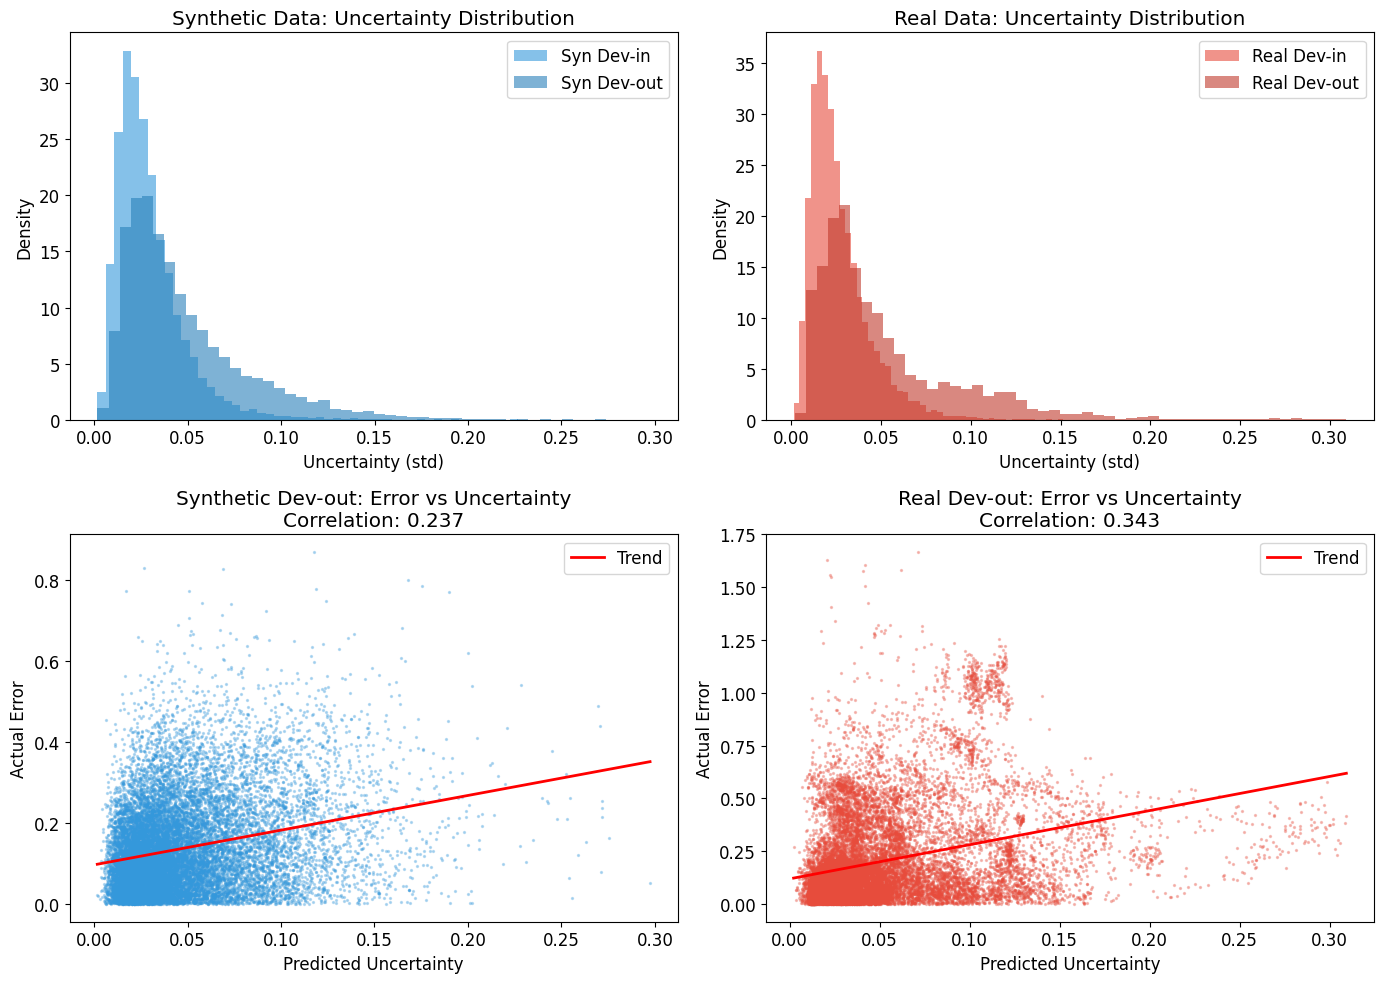

In [27]:
# Visualize uncertainty - comparing synthetic vs real data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get predictions and uncertainties for all dev sets
y_pred_syn_in, epistemic_syn_in, _ = ensemble.predict_with_uncertainty(X_syn_dev_in)
y_pred_syn_out, epistemic_syn_out, _ = ensemble.predict_with_uncertainty(X_syn_dev_out)
y_pred_real_in, epistemic_real_in, _ = ensemble.predict_with_uncertainty(X_real_dev_in)
y_pred_real_out, epistemic_real_out, _ = ensemble.predict_with_uncertainty(X_real_dev_out)

unc_syn_in = np.sqrt(epistemic_syn_in)
unc_syn_out = np.sqrt(epistemic_syn_out)
unc_real_in = np.sqrt(epistemic_real_in)
unc_real_out = np.sqrt(epistemic_real_out)

# Top left: Synthetic uncertainty distribution
ax = axes[0, 0]
ax.hist(unc_syn_in, bins=50, alpha=0.6, label='Syn Dev-in', density=True, color='#3498db')
ax.hist(unc_syn_out, bins=50, alpha=0.6, label='Syn Dev-out', density=True, color='#2980b9')
ax.set_xlabel('Uncertainty (std)')
ax.set_ylabel('Density')
ax.set_title('Synthetic Data: Uncertainty Distribution')
ax.legend()

# Top right: Real uncertainty distribution
ax = axes[0, 1]
ax.hist(unc_real_in, bins=50, alpha=0.6, label='Real Dev-in', density=True, color='#e74c3c')
ax.hist(unc_real_out, bins=50, alpha=0.6, label='Real Dev-out', density=True, color='#c0392b')
ax.set_xlabel('Uncertainty (std)')
ax.set_ylabel('Density')
ax.set_title('Real Data: Uncertainty Distribution')
ax.legend()

# Bottom left: Error vs Uncertainty for Synthetic
ax = axes[1, 0]
errors_syn_out = np.abs(y_pred_syn_out - y_syn_dev_out)
ax.scatter(unc_syn_out, errors_syn_out, s=2, alpha=0.3, color='#3498db')
ax.set_xlabel('Predicted Uncertainty')
ax.set_ylabel('Actual Error')
ax.set_title(f'Synthetic Dev-out: Error vs Uncertainty\nCorrelation: {ensemble_results["syn_dev_out"]["correlation"]:.3f}')
z = np.polyfit(unc_syn_out, errors_syn_out, 1)
p = np.poly1d(z)
x_line = np.linspace(unc_syn_out.min(), unc_syn_out.max(), 100)
ax.plot(x_line, p(x_line), 'r-', linewidth=2, label='Trend')
ax.legend()

# Bottom right: Error vs Uncertainty for Real
ax = axes[1, 1]
errors_real_out = np.abs(y_pred_real_out - y_real_dev_out)
ax.scatter(unc_real_out, errors_real_out, s=2, alpha=0.3, color='#e74c3c')
ax.set_xlabel('Predicted Uncertainty')
ax.set_ylabel('Actual Error')
ax.set_title(f'Real Dev-out: Error vs Uncertainty\nCorrelation: {ensemble_results["real_dev_out"]["correlation"]:.3f}')
z = np.polyfit(unc_real_out, errors_real_out, 1)
p = np.poly1d(z)
x_line = np.linspace(unc_real_out.min(), unc_real_out.max(), 100)
ax.plot(x_line, p(x_line), 'r-', linewidth=2, label='Trend')
ax.legend()

plt.tight_layout()
plt.show()


## 7. Model Comparison


In [28]:
# Compile all results
all_results = {
    'Mean Baseline': baseline_results.get('Mean', {}),
    'Linear': baseline_results.get('Linear', {}),
    'Random Forest': baseline_results.get('Random Forest', {}),
    'XGBoost': baseline_results.get('XGBoost', {}),
    'MLP': mlp_results,
    'Ensemble': {k: {'mae_kw': v['mae_kw']} for k, v in ensemble_results.items()}
}

# Remove empty entries
all_results = {k: v for k, v in all_results.items() if v}

# Create comparison dataframes - one for synthetic, one for real
def create_comparison_df(all_results, dev_in_key, dev_out_key, domain_name):
    comparison_data = []
    for model_name, results in all_results.items():
        row = {'Model': model_name}
        row['val_mae'] = results.get('val', {}).get('mae_kw', np.nan)
        row['dev_in_mae'] = results.get(dev_in_key, {}).get('mae_kw', np.nan)
        row['dev_out_mae'] = results.get(dev_out_key, {}).get('mae_kw', np.nan)
        comparison_data.append(row)
    
    df = pd.DataFrame(comparison_data)
    df['shift_gap'] = df['dev_out_mae'] - df['dev_in_mae']
    df['shift_gap_pct'] = (df['shift_gap'] / df['dev_in_mae']) * 100
    return df

# Create comparison tables
syn_comparison_df = create_comparison_df(all_results, 'syn_dev_in', 'syn_dev_out', 'Synthetic')
real_comparison_df = create_comparison_df(all_results, 'real_dev_in', 'real_dev_out', 'Real')

print("\n" + "="*80)
print("MODEL COMPARISON - TRAINED ON COMBINED DATA")
print("="*80)

print("\n📊 SYNTHETIC DATA PERFORMANCE (MAE in kW):")
print(syn_comparison_df.to_string(index=False))

print("\n📊 REAL DATA PERFORMANCE (MAE in kW):")
print(real_comparison_df.to_string(index=False))



MODEL COMPARISON - TRAINED ON COMBINED DATA

📊 SYNTHETIC DATA PERFORMANCE (MAE in kW):
        Model     val_mae  dev_in_mae  dev_out_mae   shift_gap  shift_gap_pct
Mean Baseline 6884.694465 6332.500583  5902.455224 -430.045359      -6.791083
       Linear 1561.674923 1565.307019  1417.632572 -147.674447      -9.434216
Random Forest  490.406533  723.101419  1179.155084  456.053665      63.069115
      XGBoost  762.107349  868.407955   990.554769  122.146814      14.065603
          MLP 1044.920750 1111.724062  1222.439940  110.715879       9.958935
     Ensemble  970.840291 1079.962519  1132.913908   52.951389       4.903077

📊 REAL DATA PERFORMANCE (MAE in kW):
        Model     val_mae  dev_in_mae  dev_out_mae    shift_gap  shift_gap_pct
Mean Baseline 6884.694465 7483.872968  5870.377724 -1613.495244     -21.559629
       Linear 1561.674923 1587.975714  1643.806152    55.830437       3.515824
Random Forest  490.406533  267.430794  2232.261581  1964.830787     734.706261
      XGBoos

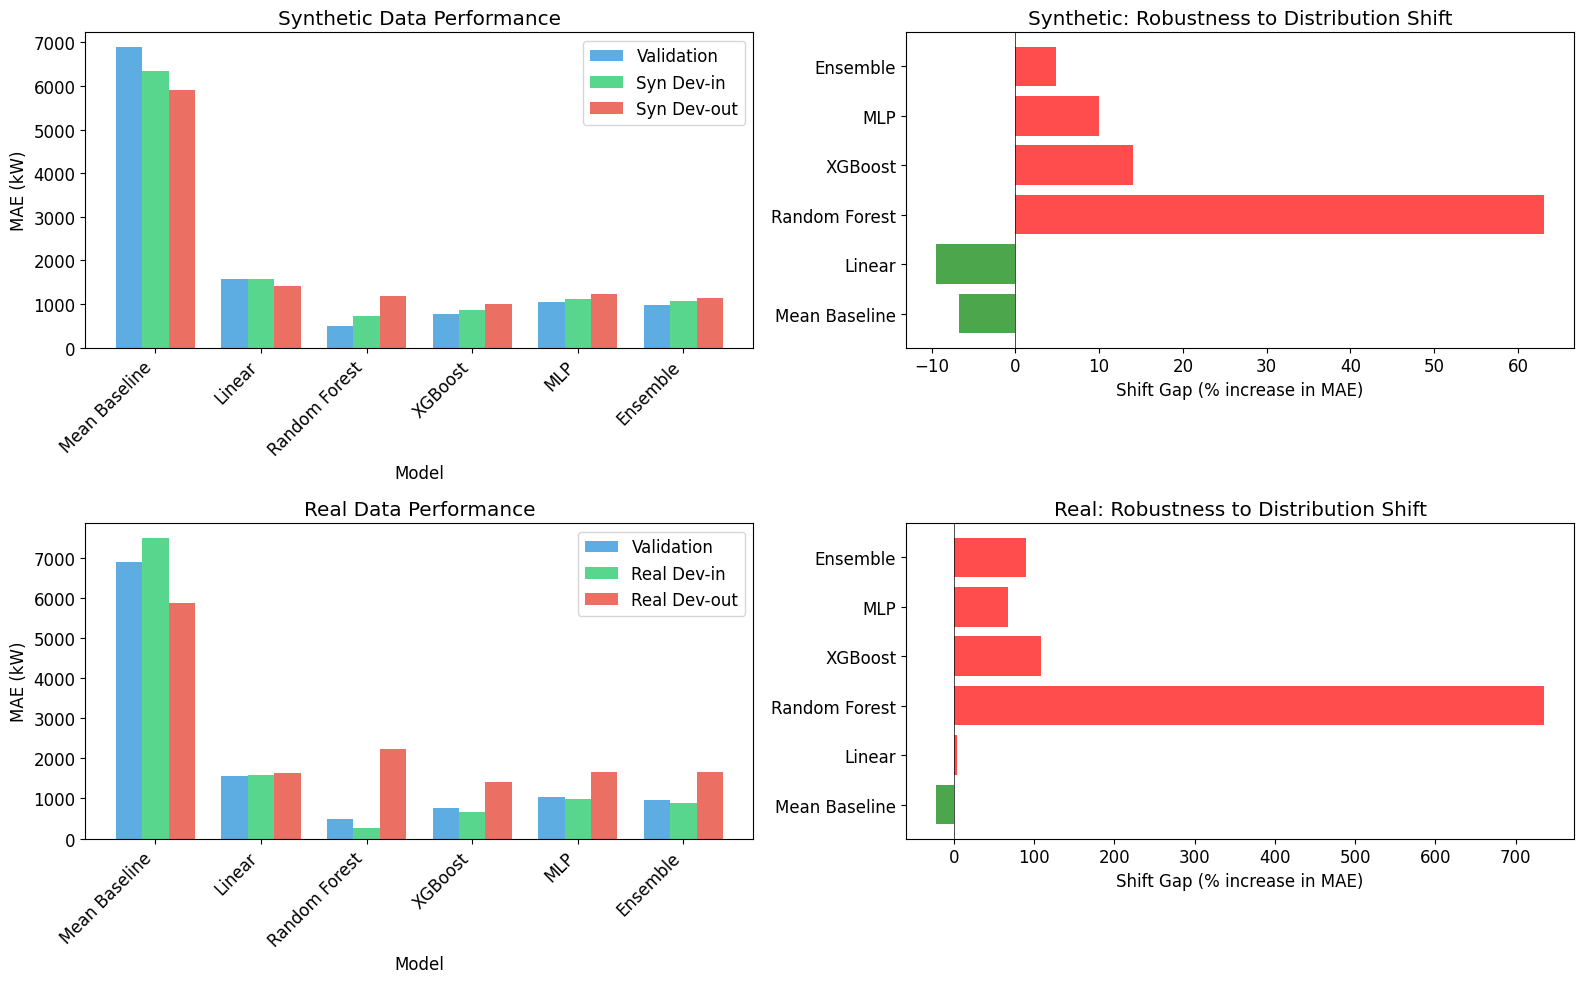

In [29]:
# Visualization of model comparison - Synthetic vs Real
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top row: Synthetic data performance
ax = axes[0, 0]
x = np.arange(len(syn_comparison_df))
width = 0.25
ax.bar(x - width, syn_comparison_df['val_mae'], width, label='Validation', alpha=0.8, color='#3498db')
ax.bar(x, syn_comparison_df['dev_in_mae'], width, label='Syn Dev-in', alpha=0.8, color='#2ecc71')
ax.bar(x + width, syn_comparison_df['dev_out_mae'], width, label='Syn Dev-out', alpha=0.8, color='#e74c3c')
ax.set_xlabel('Model')
ax.set_ylabel('MAE (kW)')
ax.set_title('Synthetic Data Performance')
ax.set_xticks(x)
ax.set_xticklabels(syn_comparison_df['Model'], rotation=45, ha='right')
ax.legend()

ax = axes[0, 1]
colors = ['green' if x < 0 else 'red' for x in syn_comparison_df['shift_gap']]
ax.barh(syn_comparison_df['Model'], syn_comparison_df['shift_gap_pct'], color=colors, alpha=0.7)
ax.set_xlabel('Shift Gap (% increase in MAE)')
ax.set_title('Synthetic: Robustness to Distribution Shift')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Bottom row: Real data performance
ax = axes[1, 0]
ax.bar(x - width, real_comparison_df['val_mae'], width, label='Validation', alpha=0.8, color='#3498db')
ax.bar(x, real_comparison_df['dev_in_mae'], width, label='Real Dev-in', alpha=0.8, color='#2ecc71')
ax.bar(x + width, real_comparison_df['dev_out_mae'], width, label='Real Dev-out', alpha=0.8, color='#e74c3c')
ax.set_xlabel('Model')
ax.set_ylabel('MAE (kW)')
ax.set_title('Real Data Performance')
ax.set_xticks(x)
ax.set_xticklabels(real_comparison_df['Model'], rotation=45, ha='right')
ax.legend()

ax = axes[1, 1]
colors = ['green' if x < 0 else 'red' for x in real_comparison_df['shift_gap']]
ax.barh(real_comparison_df['Model'], real_comparison_df['shift_gap_pct'], color=colors, alpha=0.7)
ax.set_xlabel('Shift Gap (% increase in MAE)')
ax.set_title('Real: Robustness to Distribution Shift')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()


## 8. Distribution Shift Analysis


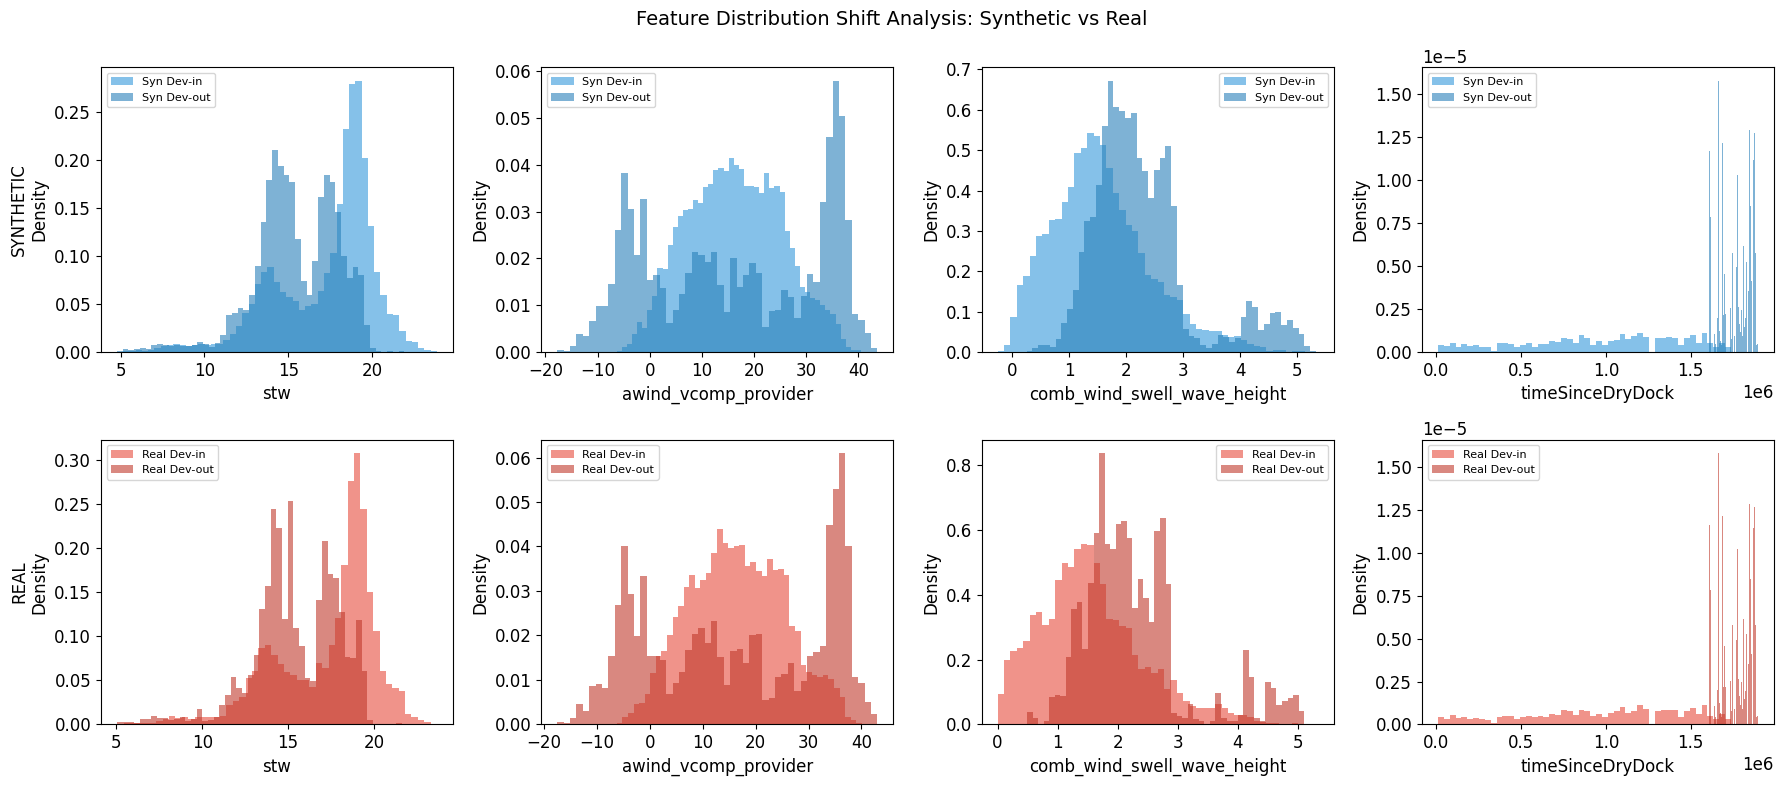

In [30]:
# Compare feature distributions between dev sets (both synthetic and real)
key_features = ['stw', 'awind_vcomp_provider', 'comb_wind_swell_wave_height', 'timeSinceDryDock']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Top row: Synthetic data
for i, feature in enumerate(key_features):
    ax = axes[0, i]
    if feature in synthetic_dev_in_df.columns:
        ax.hist(synthetic_dev_in_df[feature], bins=50, alpha=0.6, label='Syn Dev-in', density=True, color='#3498db')
        ax.hist(synthetic_dev_out_df[feature], bins=50, alpha=0.6, label='Syn Dev-out', density=True, color='#2980b9')
        ax.set_xlabel(feature)
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        if i == 0:
            ax.set_ylabel('SYNTHETIC\nDensity')

# Bottom row: Real data
for i, feature in enumerate(key_features):
    ax = axes[1, i]
    if feature in real_dev_in_df.columns:
        ax.hist(real_dev_in_df[feature], bins=50, alpha=0.6, label='Real Dev-in', density=True, color='#e74c3c')
        ax.hist(real_dev_out_df[feature], bins=50, alpha=0.6, label='Real Dev-out', density=True, color='#c0392b')
        ax.set_xlabel(feature)
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        if i == 0:
            ax.set_ylabel('REAL\nDensity')

plt.suptitle('Feature Distribution Shift Analysis: Synthetic vs Real', fontsize=14)
plt.tight_layout()
plt.show()


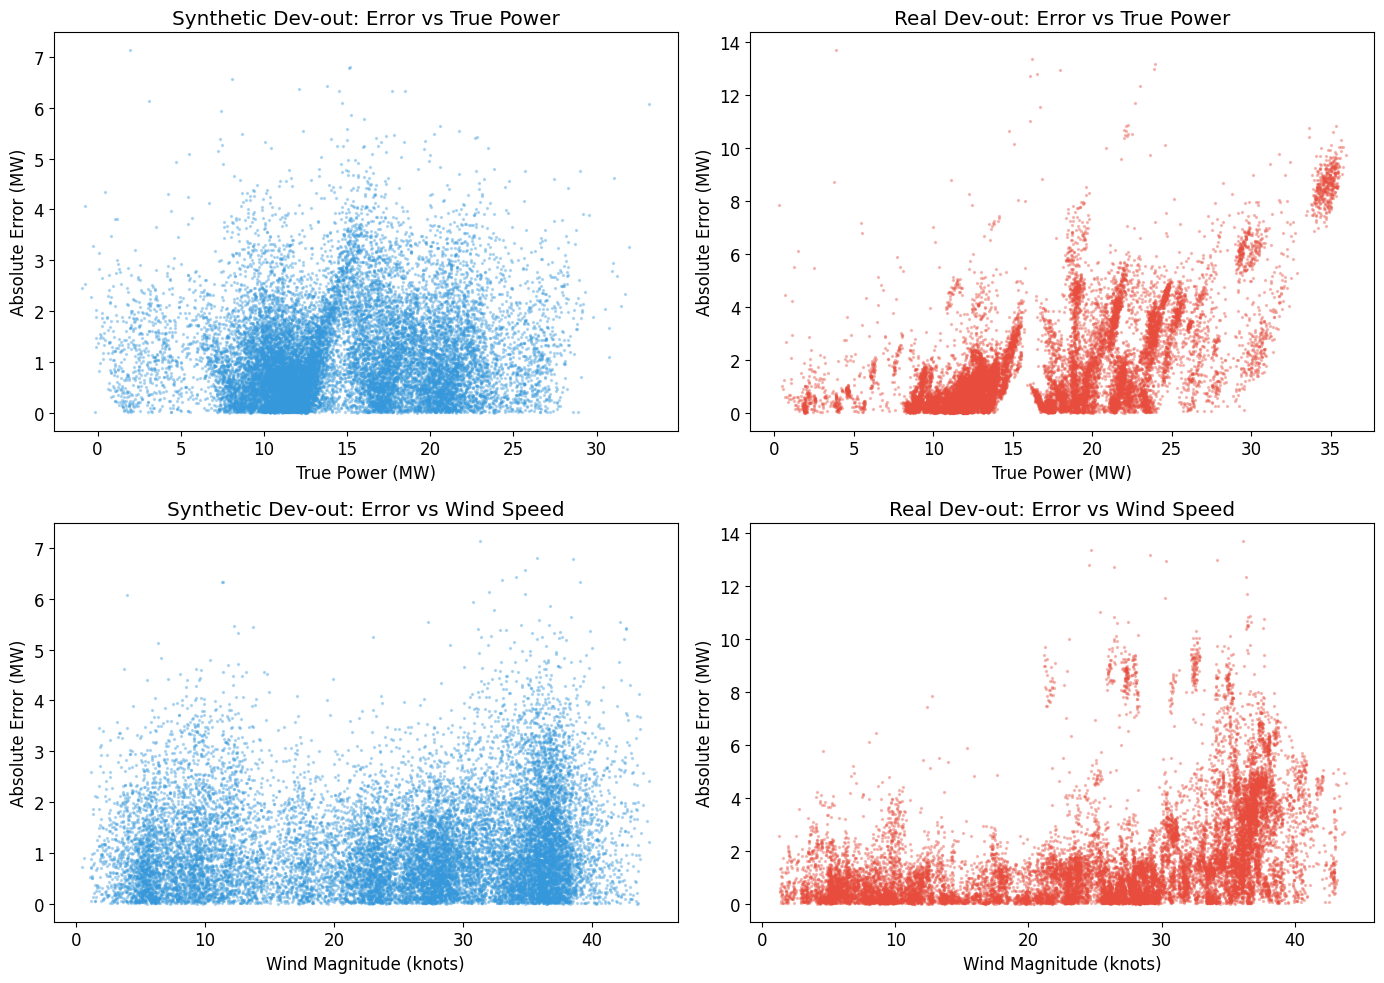

In [31]:
# Analyze where the model struggles most - comparing synthetic vs real
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get predictions and errors for both domains (using ensemble)
y_pred_syn_out_kw = data_module.inverse_transform_predictions(y_pred_syn_out)
y_true_syn_out_kw = data_module.get_raw_targets('synthetic_dev_out')
errors_syn_kw = np.abs(y_pred_syn_out_kw - y_true_syn_out_kw)

y_pred_real_out_kw = data_module.inverse_transform_predictions(y_pred_real_out)
y_true_real_out_kw = data_module.get_raw_targets('real_dev_out')
errors_real_kw = np.abs(y_pred_real_out_kw - y_true_real_out_kw)

# Top row: Error vs True Power
ax = axes[0, 0]
ax.scatter(y_true_syn_out_kw / 1000, errors_syn_kw / 1000, s=2, alpha=0.3, color='#3498db')
ax.set_xlabel('True Power (MW)')
ax.set_ylabel('Absolute Error (MW)')
ax.set_title('Synthetic Dev-out: Error vs True Power')

ax = axes[0, 1]
ax.scatter(y_true_real_out_kw / 1000, errors_real_kw / 1000, s=2, alpha=0.3, color='#e74c3c')
ax.set_xlabel('True Power (MW)')
ax.set_ylabel('Absolute Error (MW)')
ax.set_title('Real Dev-out: Error vs True Power')

# Bottom row: Error vs Wind Speed
ax = axes[1, 0]
wind_speed_syn = synthetic_dev_out_df['wind_magnitude'].values if 'wind_magnitude' in synthetic_dev_out_df.columns else \
             np.sqrt(synthetic_dev_out_df['awind_vcomp_provider']**2 + synthetic_dev_out_df['awind_ucomp_provider']**2).values
ax.scatter(wind_speed_syn, errors_syn_kw / 1000, s=2, alpha=0.3, color='#3498db')
ax.set_xlabel('Wind Magnitude (knots)')
ax.set_ylabel('Absolute Error (MW)')
ax.set_title('Synthetic Dev-out: Error vs Wind Speed')

ax = axes[1, 1]
wind_speed_real = real_dev_out_df['wind_magnitude'].values if 'wind_magnitude' in real_dev_out_df.columns else \
             np.sqrt(real_dev_out_df['awind_vcomp_provider']**2 + real_dev_out_df['awind_ucomp_provider']**2).values
ax.scatter(wind_speed_real, errors_real_kw / 1000, s=2, alpha=0.3, color='#e74c3c')
ax.set_xlabel('Wind Magnitude (knots)')
ax.set_ylabel('Absolute Error (MW)')
ax.set_title('Real Dev-out: Error vs Wind Speed')

plt.tight_layout()
plt.show()


## 9. Making Predictions on New Data

Here's how to use the trained models for inference.


In [32]:
def predict_power(model, data_module, features_dict):
    """
    Make a prediction for new input data.
    
    Args:
        model: Trained model or ensemble
        data_module: Data module with fitted scalers
        features_dict: Dictionary with feature values
        
    Returns:
        Predicted power in kW
    """
    # Create DataFrame with single row
    df = pd.DataFrame([features_dict])
    
    # Apply feature engineering
    df = data_module.feature_engineer.transform(df)
    
    # Get features in correct order
    X = df[data_module.feature_columns].values
    
    # Scale
    X_scaled = data_module.feature_scaler.transform(pd.DataFrame(X, columns=data_module.feature_columns))
    
    # Predict
    if isinstance(model, DeepEnsemble):
        y_scaled, uncertainty = model.get_total_uncertainty(X_scaled)
        y_kw = data_module.inverse_transform_predictions(y_scaled)
        return y_kw[0], np.sqrt(uncertainty[0]) * data_module.target_scaler.std
    else:
        y_scaled = model.predict(X_scaled)
        y_kw = data_module.inverse_transform_predictions(y_scaled)
        return y_kw[0], None


# Example prediction
example_input = {
    'draft_aft_telegram': 10.5,
    'draft_fore_telegram': 9.8,
    'stw': 15.0,  # Speed through water in knots
    'diff_speed_overground': 0.1,
    'awind_vcomp_provider': 10.0,
    'awind_ucomp_provider': 5.0,
    'rcurrent_vcomp': 0.5,
    'rcurrent_ucomp': 0.2,
    'comb_wind_swell_wave_height': 2.0,
    'timeSinceDryDock': 1000000  # minutes since dry dock
}

power_pred, uncertainty = predict_power(ensemble, data_module, example_input)

print("Example Prediction:")
print(f"  Input: STW={example_input['stw']} knots, Wave height={example_input['comb_wind_swell_wave_height']} m")
print(f"  Predicted Power: {power_pred/1000:.2f} MW")
if uncertainty:
    print(f"  Uncertainty (1 std): ±{uncertainty/1000:.2f} MW")


Example Prediction:
  Input: STW=15.0 knots, Wave height=2.0 m
  Predicted Power: 10.78 MW
  Uncertainty (1 std): ±0.31 MW


In [33]:
# Save models for later use
print("Saving models...")

# Save scalers
data_module.save_scalers(config.checkpoint_dir)

# Save MLP
mlp_trainer.save(os.path.join(config.checkpoint_dir, 'mlp_model.pt'))

# Save ensemble
ensemble.save(os.path.join(config.checkpoint_dir, 'ensemble'))

# Save Random Forest
from models.baseline_models import save_model
save_model(rf_model, os.path.join(config.checkpoint_dir, 'rf_model.joblib'))
save_model(xgb_model, os.path.join(config.checkpoint_dir, 'xgb_model.joblib'))
print(f"XGBoost model saved to {config.checkpoint_dir}/xgb_model.joblib")

print(f"\nModels saved to {config.checkpoint_dir}")


Saving models...
Scalers saved to checkpoints
Model saved to checkpoints\mlp_model.pt
Model saved to checkpoints\ensemble\member_0.pt
Model saved to checkpoints\ensemble\member_1.pt
Model saved to checkpoints\ensemble\member_2.pt
Model saved to checkpoints\ensemble\member_3.pt
Model saved to checkpoints\ensemble\member_4.pt
Ensemble saved to checkpoints\ensemble
Model saved to checkpoints\rf_model.joblib
Model saved to checkpoints\xgb_model.joblib
XGBoost model saved to checkpoints/xgb_model.joblib

Models saved to checkpoints


## Summary

This notebook demonstrated (v2.0 - Combined Training):

1. **Combined Data Loading**: Using `CombinedDataModule` to train on both synthetic + real data
2. **Feature Engineering**: Automatic creation of derived features (speed cubed, wind magnitude, etc.)
3. **Baseline Models**: Mean, Linear, Random Forest, and XGBoost - trained on combined data
4. **Neural Networks**: MLP with early stopping - trained on combined data
5. **Uncertainty Quantification**: Deep Ensembles for epistemic uncertainty
6. **Separate Evaluation**: Performance measured independently on synthetic and real dev sets
7. **Distribution Shift Analysis**: Comparing in-domain vs out-of-domain across both data sources

### Key Takeaways (Combined Training Approach)

- **Combined training** uses ~1M samples (synthetic + real) for better generalization
- Models are evaluated separately on synthetic and real dev sets to measure domain performance
- Tree-based models (RF, XGBoost) provide strong baselines
- Neural networks can match or exceed tree models with proper tuning
- Deep Ensembles provide useful uncertainty estimates
- Performance on real data is expected to improve with combined training
- Uncertainty is generally higher for shifted (dev-out) data in both domains


In [34]:
# Final summary table
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY - COMBINED TRAINING (v2.0)")
print("="*80)

print("\n📊 SYNTHETIC DATA RESULTS:")
print(syn_comparison_df.to_string(index=False))
print(f"\nBest model (Synthetic Dev-out MAE): {syn_comparison_df.loc[syn_comparison_df['dev_out_mae'].idxmin(), 'Model']}")
print(f"Most robust (smallest shift gap): {syn_comparison_df.loc[syn_comparison_df['shift_gap'].abs().idxmin(), 'Model']}")

print("\n" + "-"*80)
print("\n📊 REAL DATA RESULTS:")
print(real_comparison_df.to_string(index=False))
print(f"\nBest model (Real Dev-out MAE): {real_comparison_df.loc[real_comparison_df['dev_out_mae'].idxmin(), 'Model']}")
print(f"Most robust (smallest shift gap): {real_comparison_df.loc[real_comparison_df['shift_gap'].abs().idxmin(), 'Model']}")

print("\n" + "="*80)
print("TRAINING DATA SUMMARY:")
print(f"  Combined training set: {len(train_df):,} samples")
print(f"    - Synthetic: {data_module.synthetic_train_size:,}")
print(f"    - Real: {data_module.real_train_size:,}")
print("="*80)



FINAL RESULTS SUMMARY - COMBINED TRAINING (v2.0)

📊 SYNTHETIC DATA RESULTS:
        Model     val_mae  dev_in_mae  dev_out_mae   shift_gap  shift_gap_pct
Mean Baseline 6884.694465 6332.500583  5902.455224 -430.045359      -6.791083
       Linear 1561.674923 1565.307019  1417.632572 -147.674447      -9.434216
Random Forest  490.406533  723.101419  1179.155084  456.053665      63.069115
      XGBoost  762.107349  868.407955   990.554769  122.146814      14.065603
          MLP 1044.920750 1111.724062  1222.439940  110.715879       9.958935
     Ensemble  970.840291 1079.962519  1132.913908   52.951389       4.903077

Best model (Synthetic Dev-out MAE): XGBoost
Most robust (smallest shift gap): Ensemble

--------------------------------------------------------------------------------

📊 REAL DATA RESULTS:
        Model     val_mae  dev_in_mae  dev_out_mae    shift_gap  shift_gap_pct
Mean Baseline 6884.694465 7483.872968  5870.377724 -1613.495244     -21.559629
       Linear 1561.674923 1